In [ ]:
"""
File: Attention_Visualization.ipynb

Purpose:
    Defines a custom Transformer model for financial time-series prediction with
    built-in attention extraction, and provides utilities for visualizing embedding-level
    attention and computing attention rollout for interpretability analysis.

Classes:
    PositionalEncoding:
        Adds sinusoidal positional information to input embeddings.

    CustomTransformerEncoderLayer:
        Transformer encoder layer that returns multi-head self-attention weights.

    TimeSeriesTransformer:
        Encoder-only Transformer model that stores attention maps during forward passes
        and supports attention visualization.

    AttentionRollout:
        Computes layer-wise attention rollout to estimate cumulative information flow
        across Transformer layers.

    TransformerAttentionExtractor:
        Runs forward passes and standardizes extracted attention matrices.

    AttentionRolloutVisualizer:
        Visualizes attention rollout heatmaps for regime-specific analysis.
"""
!pip -q install hmmlearn


import pandas as pd
import numpy as np
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
from torch.utils.data import TensorDataset, DataLoader


if torch.backends.mps.is_available():
    device = torch.device("mps")
#else: (only using cpu for now)
device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/biweekly_smoothed.csv"
df = pd.read_csv(path, index_col=0)

print("df shape:", df.shape)
print(df.head())

df shape: (1623, 27)
               Lo 10     2-Dec     3-Dec     4-Dec     5-Dec     6-Dec  \
date                                                                     
1963-07-07 -0.142292 -0.027292 -0.106667 -0.085833 -0.072083  0.070417   
1963-07-21  0.048083  0.115346 -0.018143  0.046350 -0.018478  0.013523   
1963-08-04 -0.077000 -0.112500 -0.171357 -0.125429 -0.136571 -0.207929   
1963-08-18  0.035786  0.041214  0.073143  0.052714  0.209143  0.100786   
1963-09-01  0.112571  0.126143  0.203714  0.228286  0.248214  0.199857   

               7-Dec     8-Dec     9-Dec     Hi 10  ...   RMW_res   CMA_res  \
date                                                ...                       
1963-07-07 -0.022083  0.027083 -0.072083  0.011042  ... -0.009449 -0.059750   
1963-07-21  0.027978  0.052856  0.031336  0.042845  ...  0.000946 -0.085031   
1963-08-04 -0.145286 -0.182071 -0.090500 -0.075500  ...  0.004952 -0.071465   
1963-08-18  0.142214  0.146429  0.228000  0.249571  ...  0.041113

In [ ]:
df = df.replace(-99.99, np.nan)
df = df.dropna()
df

,Lo 10,2-Dec,3-Dec,4-Dec,5-Dec,6-Dec,7-Dec,8-Dec,9-Dec,Hi 10,...,RMW_res,CMA_res,SMB_res,HML_nutr,RMW_nutr,CMA_nutr,SMB_nutr,SMB_constructed,SMB2,SMB_constructed_nutr
date,,,,,,,,,,,,,,,,,,,,,
1963-07-07,-0.142292,-0.027292,-0.106667,-0.085833,-0.072083,0.070417,-0.022083,0.027083,-0.072083,0.011042,...,-0.009449,-0.059750,-0.097602,-0.269362,-0.024003,-0.166747,-0.177467,-0.055600,-0.089708,-0.032225
1963-07-21,0.048083,0.115346,-0.018143,0.046350,-0.018478,0.013523,0.027978,0.052856,0.031336,0.042845,...,0.000946,-0.085031,-0.013105,-0.163311,0.002404,-0.237300,-0.023829,-0.032397,0.000924,-0.006389
1963-08-04,-0.077000,-0.112500,-0.171357,-0.125429,-0.136571,-0.207929,-0.145286,-0.182071,-0.090500,-0.075500,...,0.004952,-0.071465,-0.019858,-0.091544,0.012579,-0.199441,-0.036107,-0.028790,0.015686,-0.016206
1963-08-18,0.035786,0.041214,0.073143,0.052714,0.209143,0.100786,0.142214,0.146429,0.228000,0.249571,...,0.041113,-0.014553,-0.111994,0.092831,0.104439,-0.040614,-0.203637,-0.028478,-0.091000,-0.026303
1963-09-01,0.112571,0.126143,0.203714,0.228286,0.248214,0.199857,0.250500,0.225571,0.261643,0.212214,...,-0.006316,-0.003975,-0.034374,0.136683,-0.016045,-0.011094,-0.062501,-0.014888,-0.046171,-0.008854
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-07-13,0.468095,0.515079,0.401587,0.468095,0.365794,0.357540,0.321746,0.311429,0.274286,0.285873,...,-0.080267,0.198244,0.103997,0.251864,-0.203903,0.553250,0.189095,0.073991,0.133556,0.043483
2025-07-27,0.439500,0.330429,0.249286,0.216571,0.224643,0.179429,0.171500,0.189214,0.111071,0.176643,...,-0.094825,0.014730,0.081997,-0.000871,-0.240886,0.041109,0.149094,0.000634,0.126514,0.019467
2025-08-10,-0.117214,-0.170357,-0.049500,-0.134714,-0.090214,-0.040500,-0.040714,0.030643,0.081143,0.096929,...,-0.004774,-0.155715,-0.157847,-0.321570,-0.012127,-0.434562,-0.287009,-0.106112,-0.137900,-0.054699


In [ ]:
factor_cols = ['Mkt-RF', 'SMB_constructed', 'HML', 'RMW', 'CMA', 'SMB2']
df_factors = df[factor_cols].copy()
df_factors

,Mkt-RF,SMB_constructed,HML,RMW,CMA,SMB2
date,,,,,,
1963-07-07,-0.018125,-0.055600,-0.136667,0.007708,-0.041667,-0.089708
1963-07-21,0.027188,-0.032397,-0.079812,0.014335,-0.072784,0.000924
1963-08-04,-0.108714,-0.028790,-0.025357,0.029643,-0.041714,0.015686
1963-08-18,0.206714,-0.028478,0.050786,0.039571,-0.025429,-0.091000
1963-09-01,0.208429,-0.014888,0.075929,-0.008000,-0.015071,-0.046171
...,...,...,...,...,...,...
2025-07-13,0.275635,0.073991,0.135952,-0.087540,0.178492,0.133556
2025-07-27,0.156786,0.000634,0.001500,-0.092214,0.010286,0.126514
2025-08-10,0.062929,-0.106112,-0.174571,0.005643,-0.148071,-0.137900


In [ ]:
# Standardize so each factor has mean=0, std=1
scaler = StandardScaler()
factors_scaled = scaler.fit_transform(df_factors)

Regime Segmentation


In [ ]:
import numpy as np
import warnings

# Ensure hmmlearn is available
try:
    from hmmlearn import hmm
except ImportError:
    # Colab / notebook install fallback
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hmmlearn"])
    from hmmlearn import hmm

from sklearn.metrics import silhouette_score

X_hmm = factors_scaled  # standardized factor matrix [T, d]
n_samples, n_features = X_hmm.shape

def bic_gaussian_hmm(model, X, cov_type="full"):
    """Compute BIC for GaussianHMM fitted on X.
    BIC = -2*logL + p*log(n)
    where p is the number of free parameters.
    """
    logL = model.score(X)
    k = model.n_components
    d = X.shape[1]

    # free parameters:
    # startprob: (k-1)
    # transmat: k*(k-1)
    # means: k*d
    # covars:
    if cov_type == "full":
        cov_params = k * (d * (d + 1) / 2)
    elif cov_type == "diag":
        cov_params = k * d
    else:
        # fallback (treat as diag)
        cov_params = k * d

    p = (k - 1) + (k * (k - 1)) + (k * d) + cov_params
    return -2.0 * logL + p * np.log(X.shape[0])

# Candidate k values
k_min, k_max = 2, 6
k_max = min(k_max, max(k_min, int(np.sqrt(n_samples))))  # keep sensible upper bound
k_range = range(k_min, k_max + 1)

bic_scores = []
silhouette_scores = []

warnings.filterwarnings("ignore", category=RuntimeWarning)

for k in k_range:
    try:
        model = hmm.GaussianHMM(
            n_components=k,
            covariance_type="full",
            n_iter=200,
            random_state=42,
            tol=1e-3
        )
        model.fit(X_hmm)

        # BIC (lower is better)
        bic = bic_gaussian_hmm(model, X_hmm, cov_type="full")
        bic_scores.append(bic)

        # Silhouette (higher is better)
        labels = model.predict(X_hmm)
        if len(np.unique(labels)) < 2 or len(np.unique(labels)) >= n_samples:
            sil = np.nan
        else:
            sil = silhouette_score(X_hmm, labels)
        silhouette_scores.append(sil)

        print(f"Tested k={k}: BIC={bic:.2f}, Silhouette={sil:.4f}")
    except Exception as e:
        bic_scores.append(np.nan)
        silhouette_scores.append(np.nan)
        print(f"Tested k={k}: failed ({type(e).__name__}: {e})")

# Pick k: Silhouette recommended (tie-break by BIC)
valid_sil = np.array(silhouette_scores, dtype=float)
valid_bic = np.array(bic_scores, dtype=float)

if np.all(np.isnan(valid_sil)):
    # fallback to BIC only
    best_k = list(k_range)[int(np.nanargmin(valid_bic))]
    pick_reason = "BIC (fallback)"
else:
    best_sil = np.nanmax(valid_sil)
    cand = [list(k_range)[i] for i, v in enumerate(valid_sil) if np.isfinite(v) and abs(v - best_sil) < 1e-12]
    if len(cand) == 1:
        best_k = cand[0]
    else:
        # tie-break: choose lowest BIC among candidates
        cand_idx = [list(k_range).index(k) for k in cand]
        best_k = cand[int(np.nanargmin(valid_bic[cand_idx]))]
    pick_reason = "Silhouette (tie-break by BIC)"

n_regimes = best_k
print(f"\nSelected n_regimes = {n_regimes} via {pick_reason}")

# Fit final model and assign regime labels
final_model = hmm.GaussianHMM(
    n_components=n_regimes,
    covariance_type="full",
    n_iter=500,
    random_state=42,
    tol=1e-3
)
final_model.fit(X_hmm)
regime_labels = final_model.predict(X_hmm)

df["Regime"] = regime_labels

# quick sanity check
counts = df["Regime"].value_counts().sort_index()
print("\nRegime counts:")
print(counts)



Tested k=2: BIC=19531.68, Silhouette=0.2430
Tested k=3: BIC=19753.14, Silhouette=-0.0674
Tested k=4: BIC=19263.80, Silhouette=0.0247
Tested k=5: BIC=19558.47, Silhouette=-0.1136
Tested k=6: BIC=19459.73, Silhouette=-0.0465

Selected n_regimes = 2 via Silhouette (tie-break by BIC)

Regime counts:
Regime
0    1189
1     434
Name: count, dtype: int64


XAI + Embedding Attention

In [ ]:
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

plt.ion()  # Turn on interactive mode for plotting

# Global constants
defalt_dim_feedforward = 2048
defalt_dropout = 0.1
activation_relu = "relu"
activation_gelu = "gelu"
default_max_heads = 4
attn_figsize = (6, 5)
attn_cmap = "viridis"


# Determine device: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)               # [max_len, d_model]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)     # even indices
        pe[:, 1::2] = torch.cos(position * div_term)     # odd indices
        pe = pe.unsqueeze(1)                              # [max_len, 1, d_model]
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        x: [seq_len, batch, d_model]
        """
        seq_len = x.size(0)
        return x + self.pe[:seq_len, :]

class CustomTransformerEncoderLayer(nn.Module):
    """
    Transformer encoder layer that returns attention weights.

    This class is similar to a standard TransformerEncoderLayer, but it returns attention
    weights by setting need_weights=True and average_attn_weights=False in self-attention.
    """
    def __init__(self, d_model, nhead, dim_feedforward=defalt_dim_feedforward, dropout=defalt_dropout,
                 activation=activation_relu, batch_first=False):
      """
      Initialize the encoder layer.

      Parameters:
          d_model: int
              Model embedding dimension.
          nhead: int
              Number of attention heads.
          dim_feedforward: int
              Feedforward hidden dimension.
          dropout: float
              Dropout probability.
          activation: str
              Activation name ("relu" or "gelu").
          batch_first: bool
              If True, input is [batch, seq, d_model]. If False, input is [seq, batch, d_model].
      """
      super().__init__()
      self.self_attn = nn.MultiheadAttention(
          embed_dim=d_model, num_heads=nhead, dropout=dropout, batch_first=batch_first
      )
      self.linear1 = nn.Linear(d_model, dim_feedforward)
      self.dropout = nn.Dropout(dropout)
      self.linear2 = nn.Linear(dim_feedforward, d_model)

      self.norm1 = nn.LayerNorm(d_model)
      self.norm2 = nn.LayerNorm(d_model)
      self.dropout1 = nn.Dropout(dropout)
      self.dropout2 = nn.Dropout(dropout)

      if activation == activation_relu:
          self.activation = nn.ReLU()
      elif activation == activation_gelu:
          self.activation = nn.GELU()
      else:
          raise ValueError("activation must be 'relu' or 'gelu'")

    def forward(self, src, src_mask=None, src_key_padding_mask=None):
        """
        Forward pass.

        Parameters:
            src: torch.Tensor
                Input tensor (commonly [seq_len, batch, d_model] when batch_first=False).
            src_mask: torch.Tensor or None
                Optional attention mask.
            src_key_padding_mask: torch.Tensor or None
                Optional padding mask.

        Return:
            tuple
                (encoded_src, attn_map)
                encoded_src: torch.Tensor
                attn_map: torch.Tensor (attention weights returned by MultiheadAttention)
        """
        attn_output, attn_map = self.self_attn(
            src, src, src,
            attn_mask=src_mask,
            key_padding_mask=src_key_padding_mask,
            need_weights=True,
            average_attn_weights=False
        )
        src = src + self.dropout1(attn_output)
        src = self.norm1(src)

        ff = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(ff)
        src = self.norm2(src)

        return src, attn_map

# Encoder-only Transformer Model (with Attention Extraction)
class TimeSeriesTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2,
                 dim_feedforward=128, dropout=0.1, max_len=5000):
        super().__init__()
        self.d_model = d_model
        self.input_embedding = nn.Linear(1, d_model)  # Embed each scalar feature
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)

        # Stack custom encoder layers
        self.layers = nn.ModuleList([
            CustomTransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=dim_feedforward, dropout=dropout,
                activation="relu", batch_first=False
            )
            for _ in range(num_layers)
        ])

        self.fc_out = nn.Linear(d_model, 1)

        # Attention storage (cleared every forward pass)
        self._attn_data = []

    def _clear_attn(self):
        self._attn_data = []

    def forward(self, src, src_mask=None):
        """
        src: [batch, seq_len]  (seq_len = number of features)
        Returns: [batch] prediction (scalar)
        """
        self._clear_attn()

        batch_size, seq_len = src.shape
        # [batch, seq_len, 1] -> [batch, seq_len, d_model]
        src = src.unsqueeze(-1)
        src_emb = self.input_embedding(src)           # [batch, seq_len, d_model]
        src_emb = src_emb.transpose(0, 1)             # [seq_len, batch, d_model]
        src_emb = self.pos_encoder(src_emb)           # Add positional encoding

        out = src_emb
        for layer in self.layers:
            out, attn = layer(out, src_mask=src_mask)
            # attn: [batch * nheads, tgt_len, src_len]
            self._attn_data.append(attn.detach().cpu())

        # Use last token representation (or mean-pool instead)
        last_token = out[-1]                           # [batch, d_model]
        prediction = self.fc_out(last_token).squeeze(-1)  # [batch]
        return prediction

    def get_attention_maps(self):
      """
      Standardize captured attention maps into a consistent shape.

      Return:
          list
              List of tuples: (layer_name: str, attn_array: np.ndarray)
              attn_array has shape [batch, nheads, tgt_len, src_len].
      """
      processed = []
      for li, attn in enumerate(self._attn_data):
          arr = attn.numpy()  # numpy array
          print(f"Layer {li} raw attn shape:", arr.shape)  # Debug print

          # Standardize to [batch, nheads, tgt_len, src_len]
          if arr.ndim == 3:
              # [batch*nheads, tgt_len, src_len]
              nheads = self.layers[li].self_attn.num_heads
              bnh, tgt_len, src_len = arr.shape
              assert bnh % nheads == 0, "bnh not divisible by nheads"
              b = bnh // nheads
              arr = arr.reshape(b, nheads, tgt_len, src_len)

          elif arr.ndim == 4:
              if arr.shape[0] == self.layers[li].self_attn.num_heads:
                  # [nheads, batch, tgt_len, src_len]
                  nheads, b, tgt_len, src_len = arr.shape
                  arr = arr.transpose(1, 0, 2, 3)  # -> [batch, nheads, tgt_len, src_len]
              else:
                  # Already [batch, nheads, tgt_len, src_len]
                  b, nheads, tgt_len, src_len = arr.shape

          else:
              raise ValueError(f"Unexpected attention shape: {arr.shape}")

          processed.append((f"encoder_layer_{li}", arr))
      return processed


    def plot_attention_maps(self, save_dir=None, max_heads=default_max_heads):
        """
        Plot attention heatmaps for each encoder layer.

        Parameters:
            feature_cols: list
                Feature names for axis tick labels. Length should match tgt_len and src_len.
            save_dir: str or None
                If provided, saves plots to this directory. If None, displays plots.
            max_heads: int
                Maximum number of heads to plot per layer.
        """
        attn_maps = self.get_attention_maps()
        if len(attn_maps) == 0:
            print("No attention maps captured. Did you call a forward pass first?")
            return

        for name, arr in attn_maps:
            arr = np.array(arr)  # [batch, nheads, tgt_len, src_len]
            b, nheads, tgt_len, src_len = arr.shape
            heads_to_plot = min(nheads, max_heads)
            # Plot for batch=0 only
            for h in range(heads_to_plot):
                plt.figure(figsize=attn_figsize)
                plt.imshow(arr[0, h], aspect='auto', cmap=attn_cmap)
                plt.colorbar()
                plt.title(f"{name} | Head {h}")
                plt.xticks(range(src_len), feature_cols, rotation=45)
                plt.yticks(range(tgt_len), feature_cols)
                plt.xlabel("Source position (feature index)")
                plt.ylabel("Target position (feature index)")
                plt.tight_layout()
                if save_dir is not None:
                    os.makedirs(save_dir, exist_ok=True)
                    fname = f"{name}_head{h}.png"
                    plt.savefig(os.path.join(save_dir, fname), bbox_inches='tight')
                    plt.close()
                else:
                    plt.show()
                    plt.pause(0.01)

Using device: cpu


In [ ]:
# XAI Functions
def compute_vanilla_gradients(model, src_tensor, target_index=None):
    model.eval()
    x = src_tensor.clone().detach().requires_grad_(True)
    out = model(x)
    out = out if target_index is None else out[target_index]
    out = out.mean()
    model.zero_grad()
    out.backward()
    return x.grad.detach()


def compute_integrated_gradients(model, src_tensor, baseline=None, steps=50, target_index=None):
    model.eval()
    if baseline is None:
        baseline = torch.zeros_like(src_tensor)
    alphas = torch.linspace(0, 1, steps, device=src_tensor.device)
    total_grad = torch.zeros_like(src_tensor)

    for a in alphas:
        x = baseline + a * (src_tensor - baseline)
        x = x.clone().detach().requires_grad_(True)
        out = model(x)
        out = out if target_index is None else out[target_index]
        out = out.mean()
        model.zero_grad()
        out.backward()
        total_grad += x.grad

    avg_grad = total_grad / steps
    return (src_tensor - baseline) * avg_grad


def compute_smoothgrad(model, src_tensor, base_gradient_fn, n_samples=50, noise_std=0.01, target_index=None):
    model.eval()
    smooth_grad = torch.zeros_like(src_tensor)
    for _ in range(n_samples):
        noise = torch.randn_like(src_tensor) * noise_std
        noisy_input = src_tensor + noise
        grad = base_gradient_fn(model, noisy_input, target_index=target_index)
        smooth_grad += grad
    return smooth_grad / n_samples


class GuidedBackprop:
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.forward_relu_outputs = []
        self.hooks = []

        def forward_hook(module, inp, out):
            self.forward_relu_outputs.append(out)

        def backward_hook(module, grad_in, grad_out):
            # Only allow positive gradients where the forward output was positive.
            forward_output = self.forward_relu_outputs.pop()
            guided_grad = torch.clamp(grad_in[0], min=0.0) * (forward_output > 0).float()
            return (guided_grad,)

        # Register hooks to all ReLU activations
        for m in self.model.modules():
            if isinstance(m, nn.ReLU):
                self.hooks.append(m.register_forward_hook(forward_hook))
                self.hooks.append(m.register_backward_hook(backward_hook))

    def generate_gradients(self, src_tensor, target_index=None):
        x = src_tensor.clone().detach().requires_grad_(True)
        self.forward_relu_outputs = []
        out = self.model(x)
        out = out if target_index is None else out[target_index]
        out = out.mean()
        self.model.zero_grad()
        out.backward()
        return x.grad.detach()

    def close(self):
        for h in self.hooks:
            h.remove()


def compute_smoothgrad_guided(model, src_tensor, n_samples=50, noise_std=0.01, target_index=None):
    guided_bp = GuidedBackprop(model)
    smooth_grad = torch.zeros_like(src_tensor)
    for _ in range(n_samples):
        noise = torch.randn_like(src_tensor) * noise_std
        grad = guided_bp.generate_gradients(src_tensor + noise, target_index=target_index)
        smooth_grad += grad
    guided_bp.close()
    return smooth_grad / n_samples

# Aggregate XAI (mean over fixed interval)
def aggregate_xai(model, X, xai_fn, interval=5, **kwargs):
    """
    Compute XAI attribution for each interval of samples and take the mean.
    Handles last interval with fewer than `interval` samples.
    """
    all_attrs = []

    for i in range(0, X.size(0), interval):
        x_batch = X[i:i+interval]           # [interval, seq_len] or fewer
        attr = xai_fn(model, x_batch, **kwargs)  # [batch_in_interval, seq_len]
        all_attrs.append(attr.detach().cpu())

    # Concatenate all intervals along batch dimension, then mean over all samples
    all_attrs = torch.cat(all_attrs, dim=0)  # [N_test, seq_len]
    return all_attrs.mean(dim=0)              # [seq_len]



Regime 0
Rows: 1189
Epoch 2/10  Loss=0.0343
Epoch 4/10  Loss=0.0104
Epoch 6/10  Loss=0.0061
Epoch 8/10  Loss=0.0042
Epoch 10/10  Loss=0.0039
Regime 0 RMSE: 0.0376
XAI for Regime 0, mean over test set every 5 samples:
Vanilla Gradient: [ 0.19982673  0.01578602  0.00853273 -0.00892006]
Integrated Gradients: [ 0.01174901 -0.0008066  -0.00021879  0.00084774]
SmoothGrad (vanilla): [ 0.19970283  0.01579135  0.00854018 -0.00896379]
Guided Backprop: [ 0.17062645  0.01250381  0.00769209 -0.01021238]
SmoothGrad + Guided: [ 0.17052877  0.01250192  0.0076895  -0.01025922]
Layer 0 raw attn shape: (1, 4, 4, 4)
Layer 1 raw attn shape: (1, 4, 4, 4)


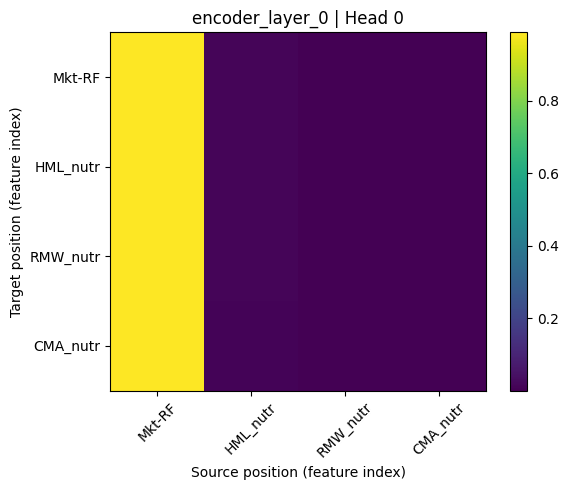

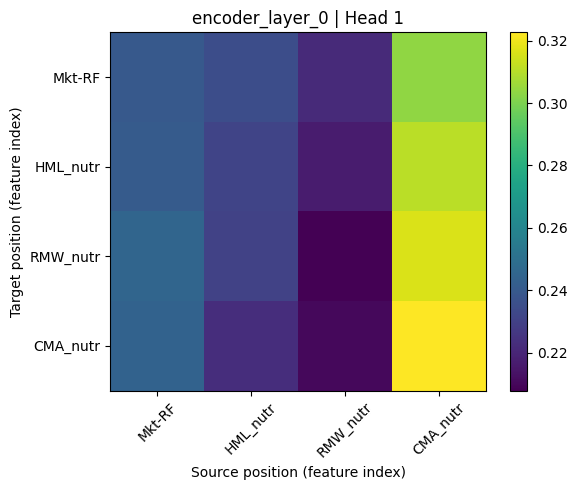

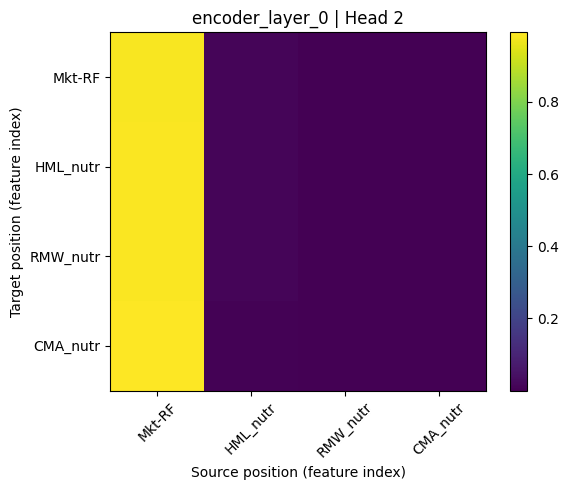

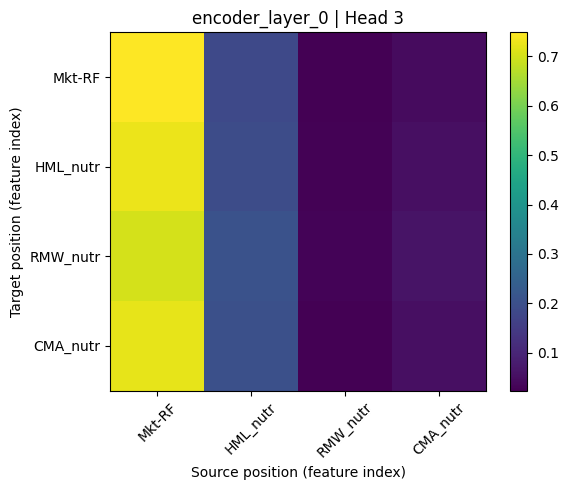

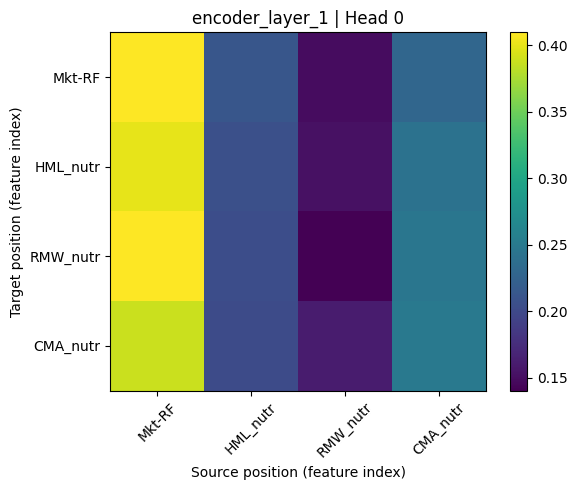

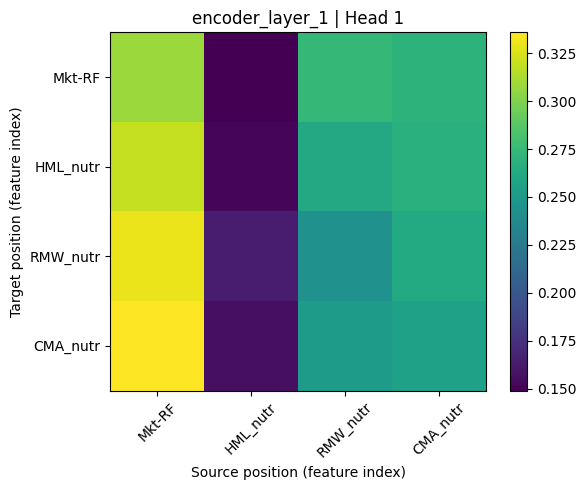

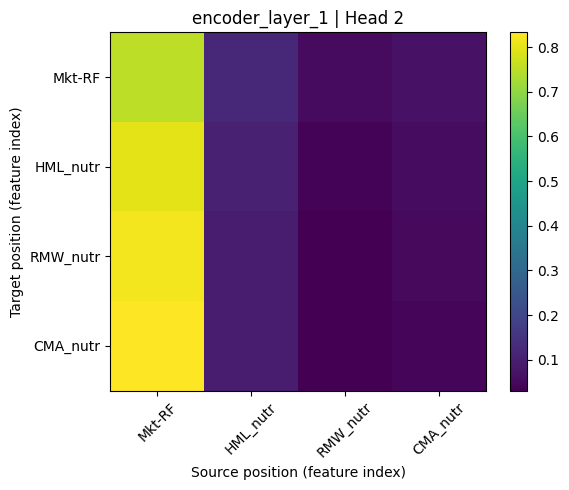

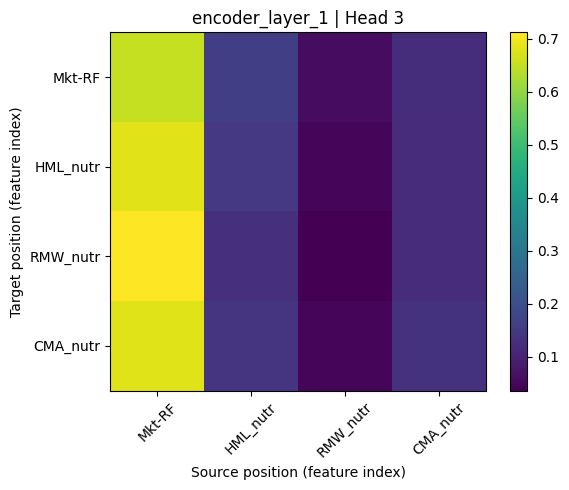


Regime 1
Rows: 434
Epoch 2/10  Loss=0.1208
Epoch 4/10  Loss=0.0422
Epoch 6/10  Loss=0.0189
Epoch 8/10  Loss=0.0158
Epoch 10/10  Loss=0.0146
Regime 1 RMSE: 0.0687
XAI for Regime 1, mean over test set every 5 samples:
Vanilla Gradient: [ 0.1911404   0.01764343 -0.001518   -0.02395005]
Integrated Gradients: [ 0.00834473 -0.00016163  0.0002605  -0.00200804]
SmoothGrad (vanilla): [ 0.19126618  0.0176469  -0.0015206  -0.02399486]
Guided Backprop: [ 0.174961    0.01463254 -0.00330004 -0.02204727]
SmoothGrad + Guided: [ 0.17499691  0.01463185 -0.00328708 -0.02206663]
Layer 0 raw attn shape: (1, 4, 4, 4)
Layer 1 raw attn shape: (1, 4, 4, 4)


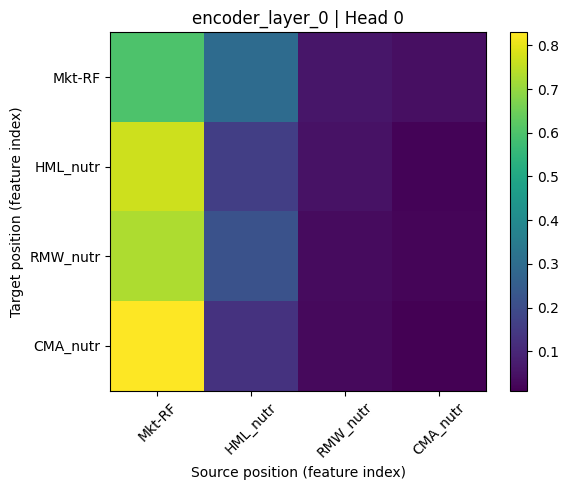

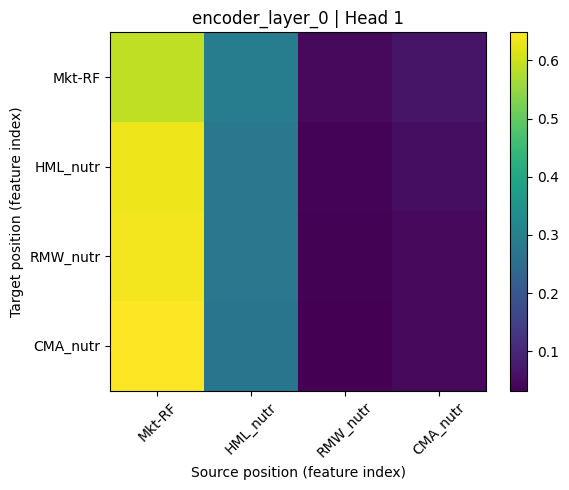

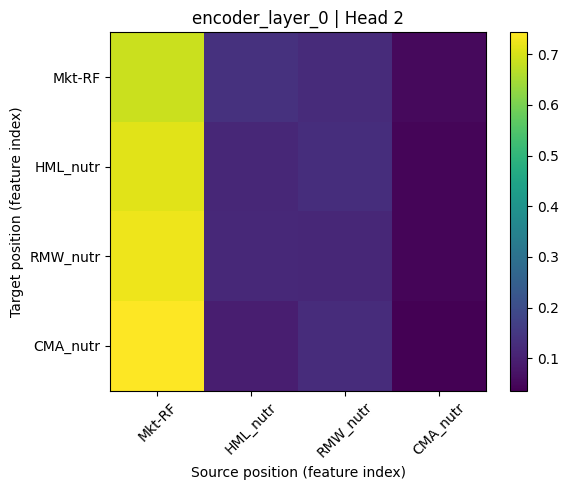

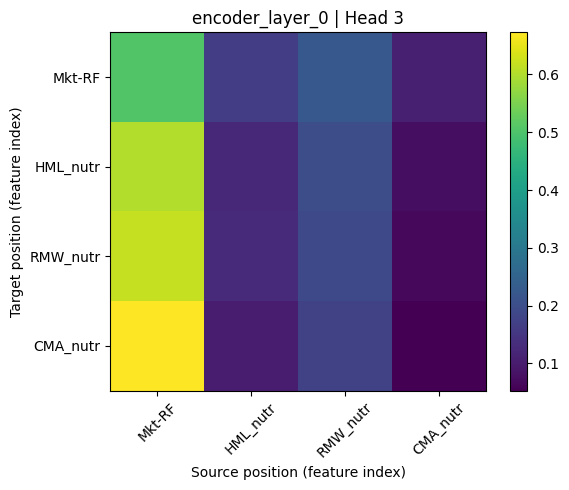

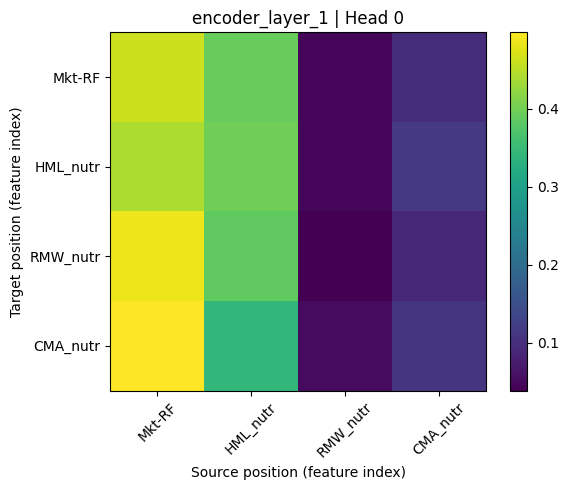

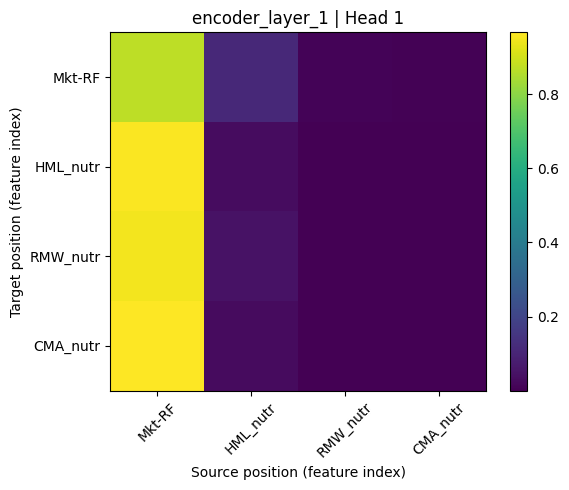

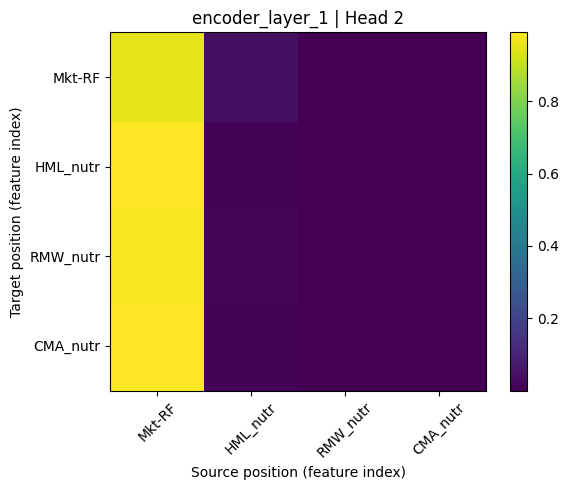

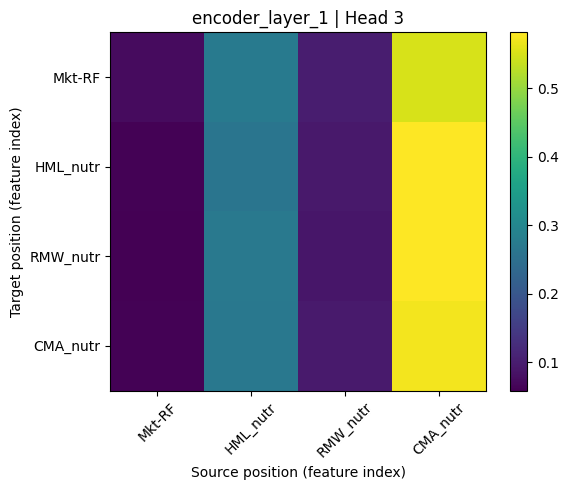

In [ ]:
# Training / Evaluation Loop
EPOCHS = 10
BATCH_SIZE = 32
d_model = 64
nhead = 4
num_layers = 2
dim_feedforward = 128
dropout = 0.1
target_col = "Hi 10"

transformer_results = {}
y_preds_dict = {}
y_tests_dict = {}

# Training per regime
for r in range(n_regimes):
    print(f"\nRegime {r}")
    df_r = df[df['Regime'] == r].copy()
    n_rows_r = len(df_r)
    print(f"Rows: {n_rows_r}")
    if n_rows_r < 5:
        print("Too few samples, skipping this regime.")
        continue

    # Feature columns
    feature_cols = ['Mkt-RF', 'HML_nutr', 'RMW_nutr', 'CMA_nutr']  # Editable
    X_r = df_r[feature_cols].values.astype(np.float32)  # [N, seq_len] where seq_len = num_features
    y_r = df_r[target_col].values.astype(np.float32)    # [N]

    # Train-test split by time
    split_idx = int(0.8 * n_rows_r)
    X_train_r, X_test_r = X_r[:split_idx], X_r[split_idx:]
    y_train_r, y_test_r = y_r[:split_idx], y_r[split_idx:]

    # Convert to torch tensors
    X_train_t = torch.tensor(X_train_r, dtype=torch.float32, device=device)
    y_train_t = torch.tensor(y_train_r, dtype=torch.float32, device=device)
    X_test_t  = torch.tensor(X_test_r,  dtype=torch.float32, device=device)
    y_test_t  = torch.tensor(y_test_r,  dtype=torch.float32, device=device)

    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

    # Build model
    model_r = TimeSeriesTransformer(
        d_model=d_model, nhead=nhead, num_layers=num_layers,
        dim_feedforward=dim_feedforward, dropout=dropout, max_len=5000
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model_r.parameters(), lr=1e-3)

    # Training Loop
    for epoch in range(EPOCHS):
        model_r.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model_r(xb)  # encoder-only: uses src only
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}  Loss={total_loss/len(train_loader):.4f}")

    # Evaluation
    model_r.eval()
    with torch.no_grad():
        if X_test_t.size(0) > 0:
            preds = model_r(X_test_t).detach().cpu().numpy()
            y_true = y_test_t.detach().cpu().numpy()
            rmse = float(np.sqrt(np.mean((preds - y_true)**2)))
            print(f"Regime {r} RMSE: {rmse:.4f}")
            y_preds_dict[r] = preds
            y_tests_dict[r] = y_true
        else:
            rmse = float('nan')
            print(f"Regime {r} RMSE: NaN (no test samples)")

    transformer_results[r] = {"model": model_r, "rmse": rmse}

    # AI + Attention Visualization
    if X_test_t.size(0) > 0:
        interval = 5

        # Vanilla Gradient
        vanilla_grad = aggregate_xai(model_r, X_test_t, compute_vanilla_gradients, interval=interval)

        # Integrated Gradients
        ig_grad = aggregate_xai(model_r, X_test_t, compute_integrated_gradients, interval=interval, steps=25)

        # SmoothGrad (based on vanilla gradients)
        smooth_vanilla_grad = aggregate_xai(
            model_r, X_test_t,
            lambda m, x: compute_smoothgrad(m, x, compute_vanilla_gradients, n_samples=10, noise_std=0.01),
            interval=interval
        )

        # Guided Backpropagation (create once per interval)
        def guided_fn(model, x_batch):
            gbp = GuidedBackprop(model)
            grad = gbp.generate_gradients(x_batch)
            gbp.close()
            return grad

        guided_grad = aggregate_xai(model_r, X_test_t, guided_fn, interval=interval)

        # SmoothGrad + Guided Backprop
        smooth_guided_grad = aggregate_xai(
            model_r, X_test_t,
            lambda m, x: compute_smoothgrad_guided(m, x, n_samples=10, noise_std=0.01),
            interval=interval
        )

        print(f"XAI for Regime {r}, mean over test set every {interval} samples:")
        print("Vanilla Gradient:", vanilla_grad.detach().cpu().numpy().flatten())
        print("Integrated Gradients:", ig_grad.detach().cpu().numpy().flatten())
        print("SmoothGrad (vanilla):", smooth_vanilla_grad.detach().cpu().numpy().flatten())
        print("Guided Backprop:", guided_grad.detach().cpu().numpy().flatten())
        print("SmoothGrad + Guided:", smooth_guided_grad.detach().cpu().numpy().flatten())


        _ = model_r(X_test_t[0:1])
        model_r.plot_attention_maps(save_dir=None, max_heads=4)


Attention rollout

In [ ]:

# Attention Rollout Core


class AttentionRollout:
    def __init__(self, discard_ratio: float = 0.0, eps: float = 1e-8):
        """
        Compute attention rollout across transformer layers.

        Parameters
        ----------
        discard_ratio : float
            Fraction of smallest attention values to discard per row
        eps : float
            Numerical stability constant
        """
        self.discard_ratio = discard_ratio
        self.eps = eps

    def _process_single_layer(self, layer_attn: np.ndarray) -> np.ndarray:
        """
        Process one attention layer.

        Input
        -----
        layer_attn : np.ndarray
            Shape [batch, nheads, tgt_len, src_len]

        Output
        ------
        np.ndarray
            Shape [batch, tgt_len, src_len]
        """
        # Average over heads
        attn_avg = layer_attn.mean(axis=1)

        # Optionally discard small attention values
        if self.discard_ratio > 0:
            flat = attn_avg.reshape(attn_avg.shape[0], -1)
            k = int(flat.shape[1] * self.discard_ratio)
            if k > 0:
                threshold = np.partition(flat, k, axis=1)[:, k][:, None, None]
                attn_avg = np.where(attn_avg < threshold, 0.0, attn_avg)

        # Row-normalize
        attn_avg = attn_avg / (attn_avg.sum(axis=-1, keepdims=True) + self.eps)
        return attn_avg

    def compute(self, attn_layers: list[np.ndarray]) -> np.ndarray:
        """
        Compute rollout across layers.

        Parameters
        ----------
        attn_layers : list[np.ndarray]
            Each with shape [batch, nheads, tgt_len, src_len]

        Returns
        -------
        rollout : np.ndarray
            Shape [batch, tgt_len, src_len]
        """
        processed_layers = [
            self._process_single_layer(layer) for layer in attn_layers
        ]

        rollout = processed_layers[0]
        for attn in processed_layers[1:]:
            rollout = np.matmul(rollout, attn)

        return rollout




In [ ]:

# Transformer Attention Extractor

class TransformerAttentionExtractor:
    def __init__(self, model):
        """
        Extract attention matrices from a transformer model.

        Model must expose:
        - model._attn_data
        - model.layers[i].self_attn.num_heads
        """
        self.model = model

    def extract(self, x: torch.Tensor) -> list[np.ndarray]:
        """
        Run forward pass and extract attention layers.

        Returns
        -------
        attn_layers : list[np.ndarray]
            Each with shape [batch, nheads, tgt_len, src_len]
        """
        _ = self.model(x)

        attn_layers_proc = []

        for li, a in enumerate(self.model._attn_data):
            arr = a.detach().cpu().numpy()

            if arr.ndim == 3:
                # [batch*nheads, tgt_len, src_len]
                nheads = self.model.layers[li].self_attn.num_heads
                bnh, tgt_len, src_len = arr.shape
                batch = bnh // nheads
                arr = arr.reshape(batch, nheads, tgt_len, src_len)

            elif arr.ndim == 4:
                # already [batch, nheads, tgt_len, src_len]
                pass

            else:
                raise ValueError(f"Unexpected attention shape: {arr.shape}")

            attn_layers_proc.append(arr)

        return attn_layers_proc




Regime 0 rollout shape: (1, 4, 4)


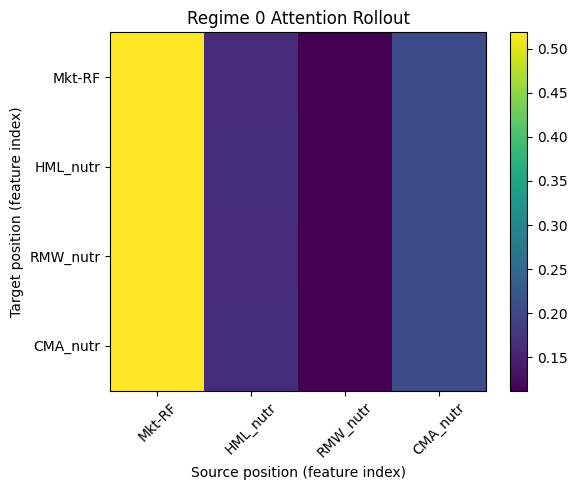

Regime 1 rollout shape: (1, 4, 4)


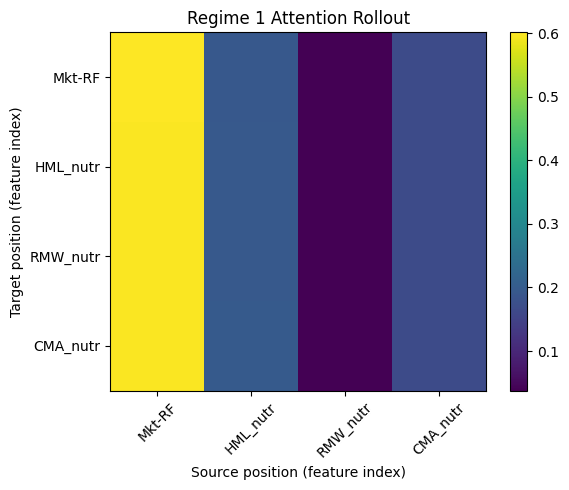

In [ ]:
# Visualization


class AttentionRolloutVisualizer:
    def __init__(self, feature_cols, cmap: str = "viridis"):
        self.feature_cols = feature_cols
        self.cmap = cmap

    def plot(self, rollout: np.ndarray, regime):
        """
        Visualize rollout for batch index 0.
        """
        plt.figure(figsize=(6, 5))
        plt.imshow(rollout[0], aspect="auto", cmap=self.cmap)
        plt.colorbar()
        plt.title(f"Regime {regime} Attention Rollout")

        plt.xticks(
            range(rollout.shape[-1]),
            self.feature_cols,
            rotation=45
        )
        plt.yticks(
            range(rollout.shape[-2]),
            self.feature_cols
        )

        plt.xlabel("Source position (feature index)")
        plt.ylabel("Target position (feature index)")
        plt.tight_layout()
        plt.show()
        plt.pause(0.01)



rollout_engine = AttentionRollout(discard_ratio=0.0)
visualizer = AttentionRolloutVisualizer(feature_cols)

for r, res in transformer_results.items():
    model_r = res["model"]

    if X_test_t.size(0) == 0:
        continue

    extractor = TransformerAttentionExtractor(model_r)

    x_sample = X_test_t[0:1]
    attn_layers = extractor.extract(x_sample)

    rollout_map = rollout_engine.compute(attn_layers)
    print(f"Regime {r} rollout shape: {rollout_map.shape}")

    visualizer.plot(rollout_map, regime=r)
